# ResNet-18 CIFAR-10 Teacher vs Linear Students

Load saved probability artifacts for the CIFAR-10 validation split and OOD datasets,
then compare teacher and student probability distributions for both student training methods.


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

sns.set_theme(style="darkgrid", context="notebook")

ROOT = Path.cwd()
if not (ROOT / "runs").exists():
    ROOT = ROOT.parent

EXPERIMENT_NAME = "linear_student_resnet18_cifar10"
PROBABILITY_DIR = ROOT / "runs" / EXPERIMENT_NAME / "probabilities"
MANIFEST_PATH = PROBABILITY_DIR / "manifest.json"
CHECKPOINT = "best"

METHODS = {
    "mse": "MSE",
    "cross_entropy_probabilities": "Cross-Entropy Probabilities",
}
DATASETS = {
    "cifar10_validation": "ID: CIFAR-10 validation",
    "mnist_test": "OOD: MNIST test",
    "svhn_test": "OOD: SVHN test",
}
DATASET_CLASS_NAMES = {
    "cifar10_validation": [
        "airplane",
        "automobile",
        "bird",
        "cat",
        "deer",
        "dog",
        "frog",
        "horse",
        "ship",
        "truck",
    ],
    "mnist_test": [str(index) for index in range(10)],
    "svhn_test": [str(index) for index in range(10)],
}

MANIFEST_PATH


PosixPath('/Users/bsh2022/Projects/distill-ood-detection/runs/linear_student_resnet18_cifar10/probabilities/manifest.json')

In [2]:
with MANIFEST_PATH.open("r", encoding="utf-8") as handle:
    manifest = json.load(handle)

manifest["experiment_name"], manifest["checkpoint_selection"]


('linear_student_resnet18_cifar10', 'best')

In [3]:
def load_probability_artifact(path: str | Path) -> dict[str, object]:
    """Load one saved probability artifact on CPU."""

    artifact_path = Path(path)
    if not artifact_path.is_absolute():
        artifact_path = ROOT / artifact_path
    return torch.load(artifact_path, map_location="cpu", weights_only=False)


artifacts = []
for entry in manifest["artifacts"]:
    artifact = load_probability_artifact(entry["path"])
    artifacts.append({**entry, **artifact})

len(artifacts)


9

In [4]:
teacher_probabilities = {
    artifact["dataset"]: artifact
    for artifact in artifacts
    if artifact["model"] == "teacher"
}

student_probabilities = {
    (artifact["dataset"], artifact["method"], artifact["checkpoint"]): artifact
    for artifact in artifacts
    if artifact["model"] == "student"
}


def to_numpy(tensor: torch.Tensor) -> np.ndarray:
    """Move a tensor to CPU and convert it to a NumPy array."""

    return tensor.detach().cpu().numpy()


def total_variation_distance(
    teacher_probs: np.ndarray,
    student_probs: np.ndarray,
) -> np.ndarray:
    """Compute per-sample total variation distance between teacher and student."""

    return 0.5 * np.abs(teacher_probs - student_probs).sum(axis=1)


def logit_l2_distance(
    teacher_logits: np.ndarray,
    student_logits: np.ndarray,
) -> np.ndarray:
    """Compute per-sample L2 distance between teacher and student logits."""

    return np.linalg.norm(teacher_logits - student_logits, axis=1)


def build_argmax_heatmap(
    teacher_probs: np.ndarray,
    student_probs: np.ndarray,
    num_classes: int,
) -> np.ndarray:
    """Compute row-normalized teacher-vs-student argmax percentages."""

    teacher_argmax = teacher_probs.argmax(axis=1)
    student_argmax = student_probs.argmax(axis=1)

    counts = np.zeros((num_classes, num_classes), dtype=np.int64)
    np.add.at(counts, (teacher_argmax, student_argmax), 1)

    row_totals = counts.sum(axis=1, keepdims=True)
    return np.divide(
        counts * 100.0,
        row_totals,
        out=np.zeros_like(counts, dtype=float),
        where=row_totals > 0,
    )


def build_comparison(dataset_key: str, method_key: str) -> dict[str, object]:
    """Assemble teacher/student comparison data for one dataset and method."""

    teacher = teacher_probabilities[dataset_key]
    student = student_probabilities[(dataset_key, method_key, CHECKPOINT)]

    teacher_logits = to_numpy(teacher["logits"])
    student_logits = to_numpy(student["logits"])
    teacher_probs = to_numpy(teacher["probabilities"])
    student_probs = to_numpy(student["probabilities"])
    labels = to_numpy(teacher["labels"]).astype(int)
    class_names = DATASET_CLASS_NAMES[dataset_key]

    sample_indices = np.arange(labels.shape[0])
    teacher_minus_student = teacher_probs - student_probs

    return {
        "teacher_logits": teacher_logits,
        "student_logits": student_logits,
        "teacher_probs": teacher_probs,
        "student_probs": student_probs,
        "labels": labels,
        "predicted_values": pd.DataFrame(
            {
                "probability": np.concatenate(
                    [teacher_probs.ravel(), student_probs.ravel()]
                ),
                "model": ["Teacher"] * teacher_probs.size
                + ["Student"] * student_probs.size,
            }
        ),
        "max_probability_difference": teacher_probs.max(axis=1)
        - student_probs.max(axis=1),
        "total_variation_distance": total_variation_distance(
            teacher_probs,
            student_probs,
        ),
        "logit_l2_distance": logit_l2_distance(
            teacher_logits,
            student_logits,
        ),
        "argmax_agreement": build_argmax_heatmap(
            teacher_probs,
            student_probs,
            num_classes=len(class_names),
        ),
        "per_class_delta": pd.DataFrame(
            {
                "class_name": [class_names[label] for label in labels],
                "teacher_minus_student": teacher_minus_student[
                    sample_indices, labels
                ],
            }
        ),
    }


comparisons = {
    (method_key, dataset_key): build_comparison(dataset_key, method_key)
    for method_key in METHODS
    for dataset_key in DATASETS
}

def dataset_group(dataset_key: str) -> str:
    """Map each dataset to the ID/OOD grouping used in the summary plot."""

    return "ID" if dataset_key == "cifar10_validation" else "OOD"


METHOD_ORDER = list(METHODS)
DISTRIBUTION_ORDER = ["ID", "OOD"]
DISTRIBUTION_CLASS_NAMES = {
    "ID": DATASET_CLASS_NAMES["cifar10_validation"],
    "OOD": DATASET_CLASS_NAMES["mnist_test"],
}


def build_probability_group_frame() -> pd.DataFrame:
    """Collect probability values into one dataframe by method and ID/OOD."""

    probability_frames = []
    for (method_key, dataset_key), comparison in comparisons.items():
        probabilities = np.concatenate(
            [
                comparison["teacher_probs"].ravel(),
                comparison["student_probs"].ravel(),
            ]
        )
        probability_frames.append(
            pd.DataFrame(
                {
                    "probability": probabilities,
                    "distribution": dataset_group(dataset_key),
                    "dataset": DATASETS[dataset_key],
                    "method": METHODS[method_key],
                }
            )
        )

    return pd.concat(probability_frames, ignore_index=True)


def build_grouped_metric_frame(
    metric_key: str,
    value_name: str,
) -> pd.DataFrame:
    """Collect one comparison metric into a dataframe by method and ID/OOD."""

    metric_frames = []
    for (method_key, dataset_key), comparison in comparisons.items():
        metric_frames.append(
            pd.DataFrame(
                {
                    value_name: comparison[metric_key],
                    "distribution": dataset_group(dataset_key),
                    "dataset": DATASETS[dataset_key],
                    "method": METHODS[method_key],
                }
            )
        )

    return pd.concat(metric_frames, ignore_index=True)


def build_grouped_argmax_heatmaps() -> dict[tuple[str, str], np.ndarray]:
    """Aggregate teacher-vs-student argmax agreement by method and ID/OOD."""

    heatmaps = {}
    for method_key in METHOD_ORDER:
        for distribution in DISTRIBUTION_ORDER:
            grouped_comparisons = [
                comparison
                for (candidate_method_key, dataset_key), comparison in comparisons.items()
                if candidate_method_key == method_key
                and dataset_group(dataset_key) == distribution
            ]
            teacher_probs = np.concatenate(
                [comparison["teacher_probs"] for comparison in grouped_comparisons],
                axis=0,
            )
            student_probs = np.concatenate(
                [comparison["student_probs"] for comparison in grouped_comparisons],
                axis=0,
            )
            heatmaps[(method_key, distribution)] = build_argmax_heatmap(
                teacher_probs,
                student_probs,
                num_classes=len(DISTRIBUTION_CLASS_NAMES[distribution]),
            )

    return heatmaps


def build_grouped_per_class_delta_frames() -> dict[tuple[str, str], pd.DataFrame]:
    """Aggregate ground-truth class deltas by method and ID/OOD."""

    grouped_frames = {}
    for method_key in METHOD_ORDER:
        for distribution in DISTRIBUTION_ORDER:
            frames = [
                comparison["per_class_delta"]
                for (candidate_method_key, dataset_key), comparison in comparisons.items()
                if candidate_method_key == method_key
                and dataset_group(dataset_key) == distribution
            ]
            grouped_frames[(method_key, distribution)] = pd.concat(
                frames,
                ignore_index=True,
            )

    return grouped_frames


probability_group_frame = build_probability_group_frame()
max_probability_difference_group_frame = build_grouped_metric_frame(
    metric_key="max_probability_difference",
    value_name="max_probability_difference",
)
total_variation_group_frame = build_grouped_metric_frame(
    metric_key="total_variation_distance",
    value_name="total_variation_distance",
)
logit_l2_group_frame = build_grouped_metric_frame(
    metric_key="logit_l2_distance",
    value_name="logit_l2_distance",
)
grouped_argmax_heatmaps = build_grouped_argmax_heatmaps()
grouped_per_class_delta_frames = build_grouped_per_class_delta_frames()

{
    (method_key, dataset_key): {
        "teacher_logits_shape": comparison["teacher_logits"].shape,
        "student_logits_shape": comparison["student_logits"].shape,
        "teacher_probs_shape": comparison["teacher_probs"].shape,
        "student_probs_shape": comparison["student_probs"].shape,
    }
    for (method_key, dataset_key), comparison in comparisons.items()
}


{('mse', 'cifar10_validation'): {'teacher_logits_shape': (5000, 10),
  'student_logits_shape': (5000, 10),
  'teacher_probs_shape': (5000, 10),
  'student_probs_shape': (5000, 10)},
 ('mse', 'mnist_test'): {'teacher_logits_shape': (10000, 10),
  'student_logits_shape': (10000, 10),
  'teacher_probs_shape': (10000, 10),
  'student_probs_shape': (10000, 10)},
 ('mse', 'svhn_test'): {'teacher_logits_shape': (26032, 10),
  'student_logits_shape': (26032, 10),
  'teacher_probs_shape': (26032, 10),
  'student_probs_shape': (26032, 10)},
 ('cross_entropy_probabilities',
  'cifar10_validation'): {'teacher_logits_shape': (5000,
   10), 'student_logits_shape': (5000, 10), 'teacher_probs_shape': (5000,
   10), 'student_probs_shape': (5000, 10)},
 ('cross_entropy_probabilities',
  'mnist_test'): {'teacher_logits_shape': (10000,
   10), 'student_logits_shape': (10000, 10), 'teacher_probs_shape': (10000,
   10), 'student_probs_shape': (10000, 10)},
 ('cross_entropy_probabilities',
  'svhn_test'): {'

The boxplots below compare the probability assigned to each sample's ground-truth class:
`p_teacher(y|x) - p_student(y|x)`.


/var/folders/dp/qpw35dg90hv8n0247r1klh4c0000gn/T/ipykernel_39150/2071804436.py:55: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


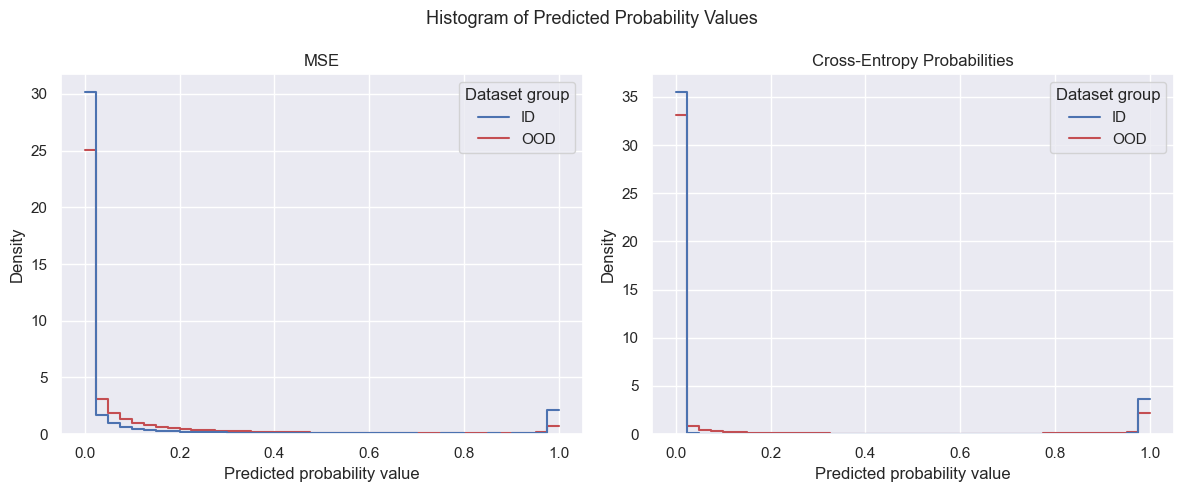

In [5]:
def make_axes_grid(figsize: tuple[int, int] = (21, 12)) -> tuple[plt.Figure, np.ndarray]:
    """Create a 2 x 3 grid aligned with training method and dataset."""

    fig, axes = plt.subplots(2, 3, figsize=figsize, constrained_layout=True)
    return fig, axes


def axis_title(method_key: str, dataset_key: str) -> str:
    """Build an explicit axis title for one grid cell."""

    return f"{METHODS[method_key]} | {DATASETS[dataset_key]}"


probability_bins = np.linspace(0.0, 1.0, 41)

deep_palette = sns.color_palette("deep")
distribution_palette = {
    "ID": deep_palette[0],
    "OOD": deep_palette[3],
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for axis_index, method_key in enumerate(METHOD_ORDER):
    ax = axes[axis_index]
    method_name = METHODS[method_key]
    method_frame = probability_group_frame.loc[
        probability_group_frame["method"] == method_name
    ]

    sns.histplot(
        data=method_frame,
        x="probability",
        hue="distribution",
        hue_order=DISTRIBUTION_ORDER,
        palette=distribution_palette,
        bins=probability_bins,
        common_bins=True,
        stat="density",
        element="step",
        fill=False,
        common_norm=False,
        ax=ax,
    )
    ax.set_title(method_name)
    ax.set_xlabel("Predicted probability value")
    ax.set_ylabel("Density")
    legend = ax.get_legend()
    if legend is not None:
        legend.set_title("Dataset group")

fig.suptitle(
    "Histogram of Predicted Probability Values",
    fontsize=13,
)
plt.tight_layout()

/var/folders/dp/qpw35dg90hv8n0247r1klh4c0000gn/T/ipykernel_39150/1624266547.py:32: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


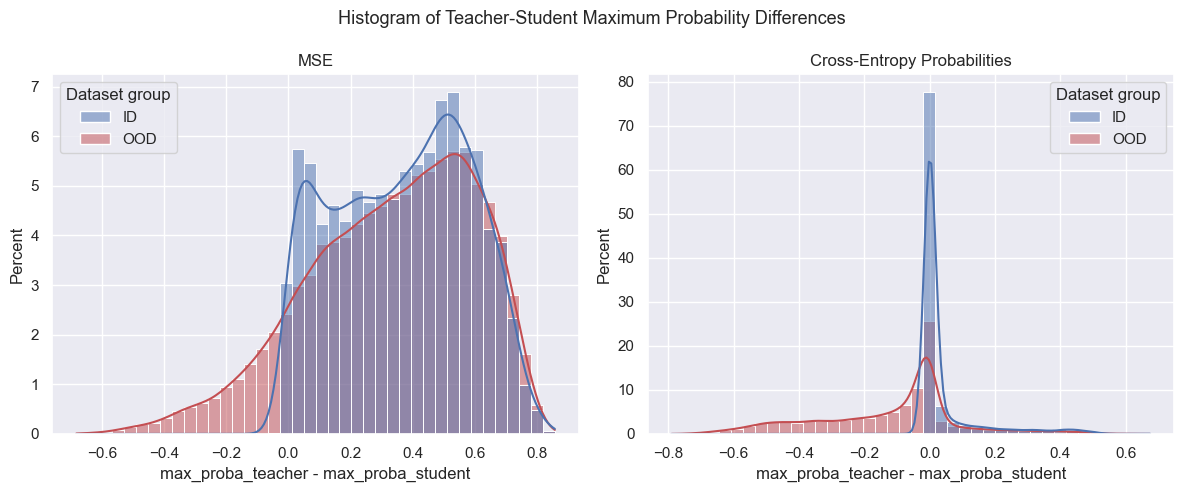

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for axis_index, method_key in enumerate(METHOD_ORDER):
    ax = axes[axis_index]
    method_name = METHODS[method_key]
    method_frame = max_probability_difference_group_frame.loc[
        max_probability_difference_group_frame["method"] == method_name
    ]

    sns.histplot(
        data=method_frame,
        x="max_probability_difference",
        hue="distribution",
        hue_order=DISTRIBUTION_ORDER,
        palette=distribution_palette,
        bins=40,
        kde=True,
        stat="percent",
        common_norm=False,
        ax=ax,
    )
    ax.set_title(method_name)
    ax.set_xlabel("max_proba_teacher - max_proba_student")
    ax.set_ylabel("Percent")
    legend = ax.get_legend()
    if legend is not None:
        legend.set_title("Dataset group")

fig.suptitle(
    "Histogram of Teacher-Student Maximum Probability Differences",
    fontsize=13,
)
plt.tight_layout()


/var/folders/dp/qpw35dg90hv8n0247r1klh4c0000gn/T/ipykernel_39150/1818999201.py:32: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


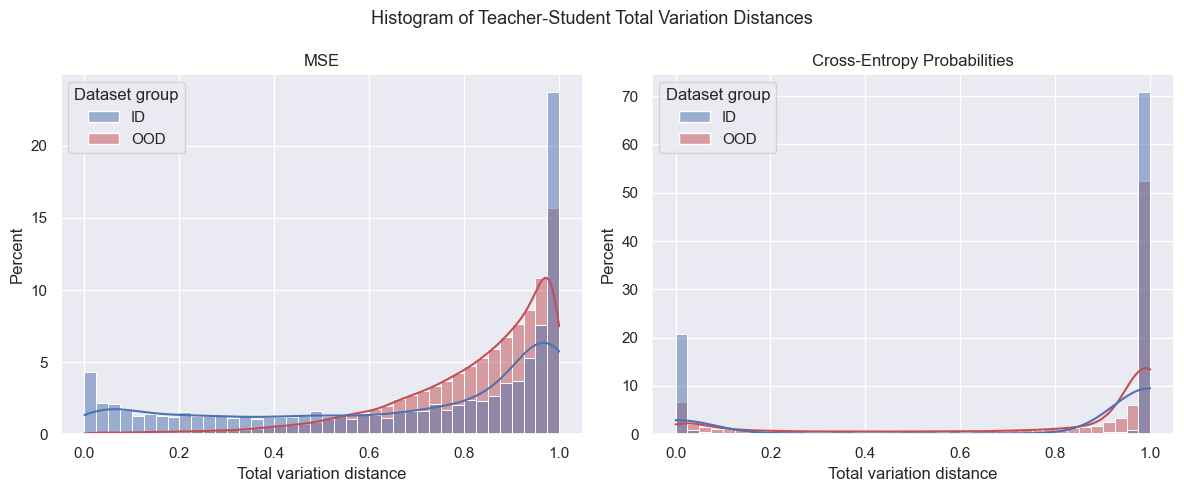

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for axis_index, method_key in enumerate(METHOD_ORDER):
    ax = axes[axis_index]
    method_name = METHODS[method_key]
    method_frame = total_variation_group_frame.loc[
        total_variation_group_frame["method"] == method_name
    ]

    sns.histplot(
        data=method_frame,
        x="total_variation_distance",
        hue="distribution",
        hue_order=DISTRIBUTION_ORDER,
        palette=distribution_palette,
        bins=40,
        kde=True,
        stat="percent",
        common_norm=False,
        ax=ax,
    )
    ax.set_title(method_name)
    ax.set_xlabel("Total variation distance")
    ax.set_ylabel("Percent")
    legend = ax.get_legend()
    if legend is not None:
        legend.set_title("Dataset group")

fig.suptitle(
    "Histogram of Teacher-Student Total Variation Distances",
    fontsize=13,
)
plt.tight_layout()


/var/folders/dp/qpw35dg90hv8n0247r1klh4c0000gn/T/ipykernel_39150/2390672460.py:31: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


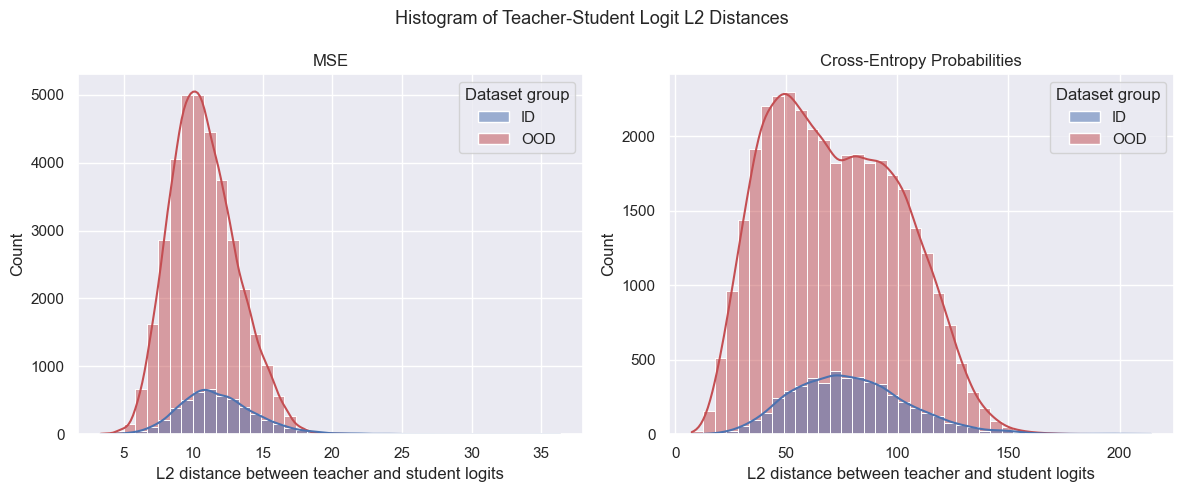

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for axis_index, method_key in enumerate(METHOD_ORDER):
    ax = axes[axis_index]
    method_name = METHODS[method_key]
    method_frame = logit_l2_group_frame.loc[
        logit_l2_group_frame["method"] == method_name
    ]

    sns.histplot(
        data=method_frame,
        x="logit_l2_distance",
        hue="distribution",
        hue_order=DISTRIBUTION_ORDER,
        palette=distribution_palette,
        bins=40,
        kde=True,
        common_norm=False,
        ax=ax,
    )
    ax.set_title(method_name)
    ax.set_xlabel("L2 distance between teacher and student logits")
    ax.set_ylabel("Count")
    legend = ax.get_legend()
    if legend is not None:
        legend.set_title("Dataset group")

fig.suptitle(
    "Histogram of Teacher-Student Logit L2 Distances",
    fontsize=13,
)
plt.tight_layout()


Text(0.5, 0.98, 'Teacher vs Student Argmax Agreement Heatmap (%)')

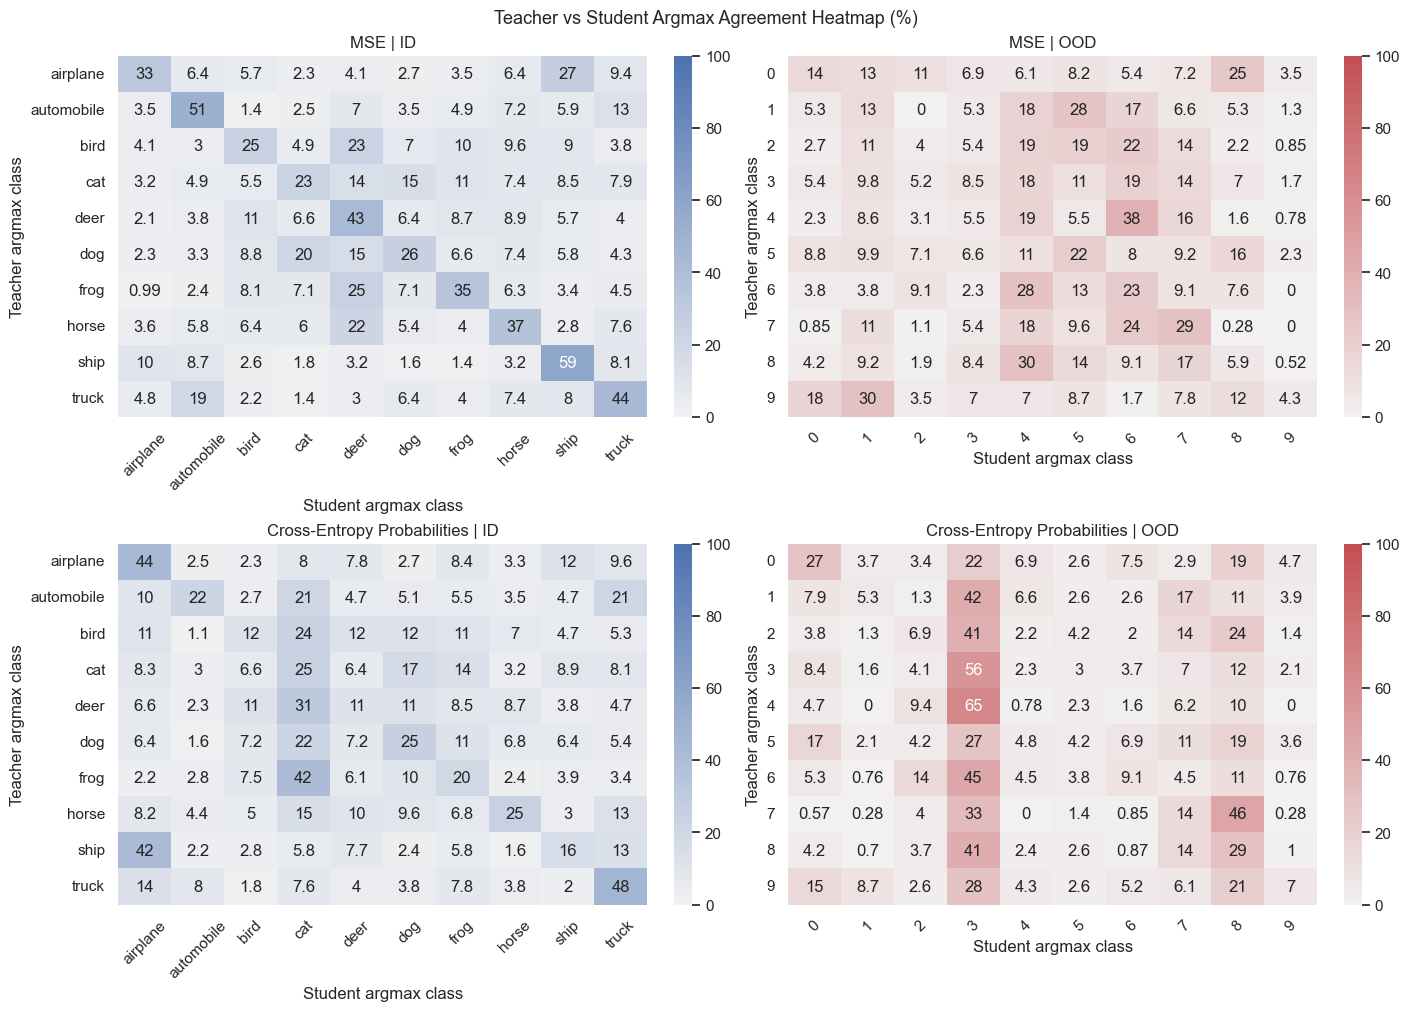

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
distribution_cmaps = {
    distribution: sns.light_palette(
        distribution_palette[distribution],
        as_cmap=True,
    )
    for distribution in DISTRIBUTION_ORDER
}

for row_index, method_key in enumerate(METHOD_ORDER):
    for col_index, distribution in enumerate(DISTRIBUTION_ORDER):
        ax = axes[row_index, col_index]
        class_names = DISTRIBUTION_CLASS_NAMES[distribution]

        sns.heatmap(
            grouped_argmax_heatmaps[(method_key, distribution)],
            ax=ax,
            cmap=distribution_cmaps[distribution],
            vmin=0,
            vmax=100,
            xticklabels=class_names,
            yticklabels=class_names,
            cbar=True,
            annot=True,
        )
        ax.set_title(f"{METHODS[method_key]} | {distribution}")
        ax.set_xlabel("Student argmax class")
        ax.set_ylabel("Teacher argmax class")
        ax.tick_params(axis="x", rotation=45)
        ax.tick_params(axis="y", rotation=0)

fig.suptitle(
    "Teacher vs Student Argmax Agreement Heatmap (%)",
    fontsize=13,
)

/var/folders/dp/qpw35dg90hv8n0247r1klh4c0000gn/T/ipykernel_39150/3984064374.py:77: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


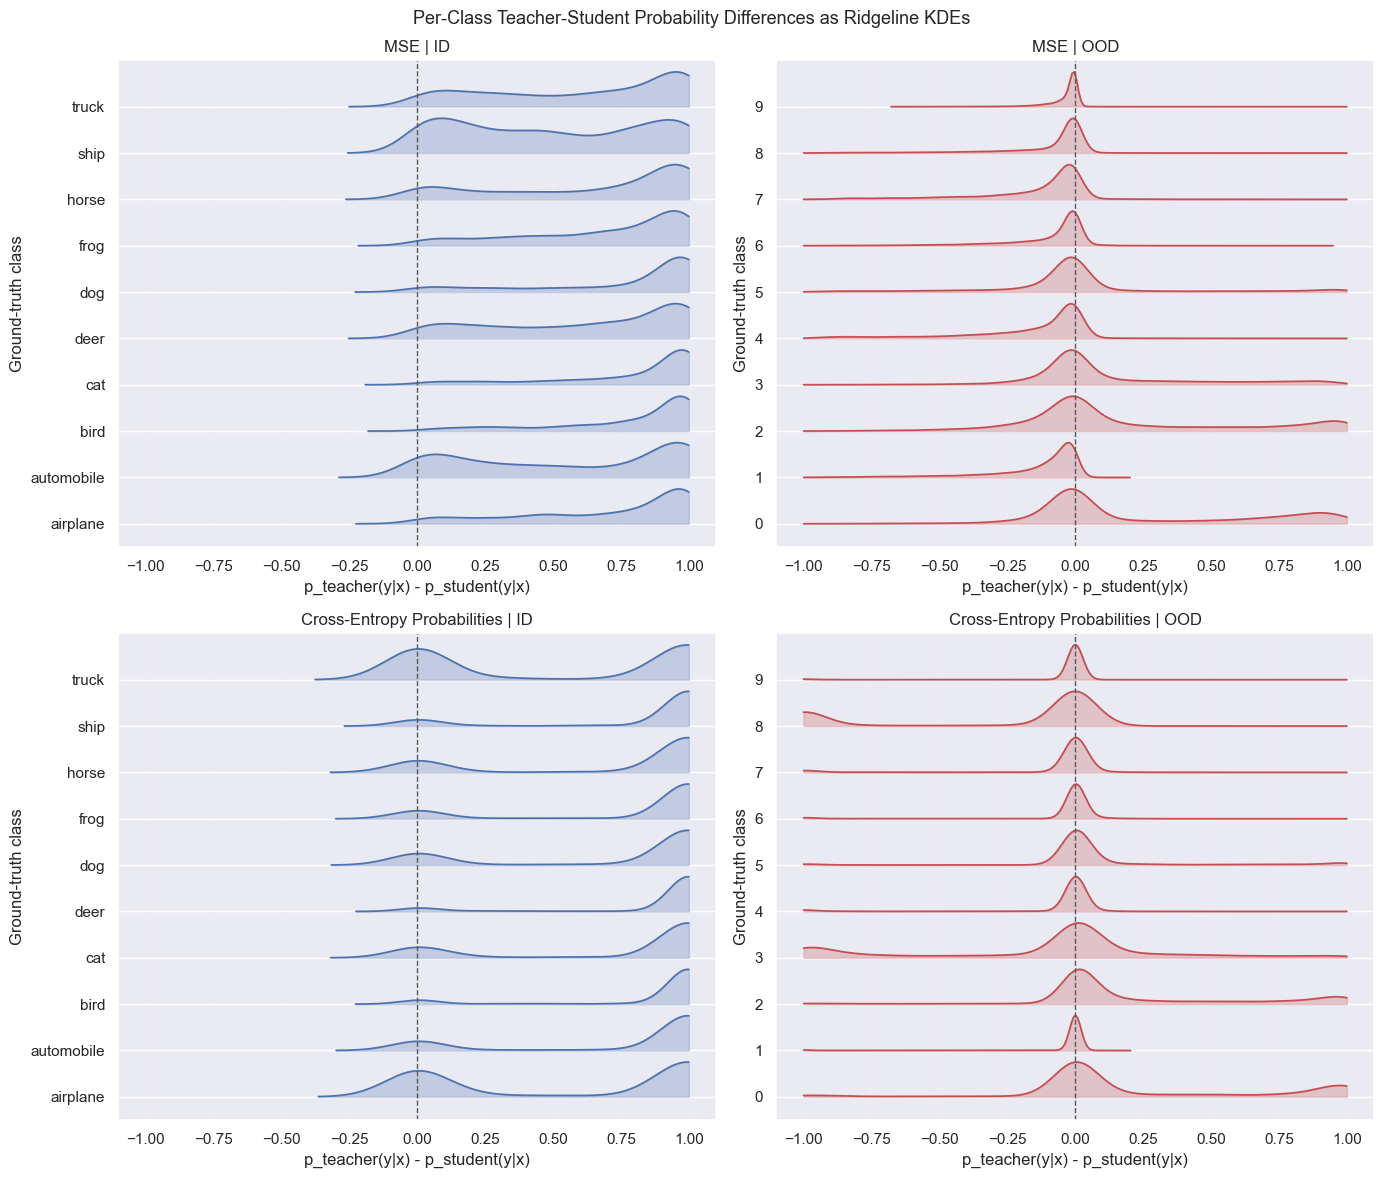

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
ridge_height = 0.75
all_delta_values = pd.concat(
    [
        frame["teacher_minus_student"]
        for frame in grouped_per_class_delta_frames.values()
    ],
    ignore_index=True,
)
x_min = all_delta_values.min()
x_max = all_delta_values.max()

for row_index, method_key in enumerate(METHOD_ORDER):
    for col_index, distribution in enumerate(DISTRIBUTION_ORDER):
        ax = axes[row_index, col_index]
        per_class_delta = grouped_per_class_delta_frames[(method_key, distribution)]
        class_names = DISTRIBUTION_CLASS_NAMES[distribution]
        ridge_color = distribution_palette[distribution]

        for class_index, class_name in enumerate(class_names):
            class_delta = per_class_delta.loc[
                per_class_delta["class_name"] == class_name,
                "teacher_minus_student",
            ]

            if class_delta.nunique() <= 1:
                continue

            sns.kdeplot(
                x=class_delta,
                ax=ax,
                fill=False,
                bw_adjust=0.85,
                clip=(x_min, x_max),
                color=ridge_color,
                linewidth=1.25,
            )

            ridge_line = ax.lines[-1]
            ridge_x = ridge_line.get_xdata()
            ridge_y = ridge_line.get_ydata()
            if ridge_y.max() == 0:
                ax.lines.pop()
                continue

            ridge_y = ridge_y / ridge_y.max() * ridge_height + class_index
            ridge_line.set_data(ridge_x, ridge_y)
            ax.fill_between(
                ridge_x,
                class_index,
                ridge_y,
                color=ridge_color,
                alpha=0.25,
            )
            ax.hlines(
                y=class_index,
                xmin=x_min,
                xmax=x_max,
                color="0.85",
                linewidth=0.7,
                zorder=0,
            )

        ax.axvline(0.0, color="0.35", linestyle="--", linewidth=1.0)
        ax.set_title(f"{METHODS[method_key]} | {distribution}")
        ax.set_xlabel("p_teacher(y|x) - p_student(y|x)")
        ax.set_ylabel("Ground-truth class")
        ax.set_yticks(range(len(class_names)))
        ax.set_yticklabels(class_names)
        ax.set_ylim(-0.5, len(class_names) - 1 + ridge_height + 0.25)
        ax.grid(axis="x", alpha=0.15)

fig.suptitle(
    "Per-Class Teacher-Student Probability Differences as Ridgeline KDEs",
    fontsize=13,
)
plt.tight_layout()
